# 04 — Acoustic Similarity Analysis

This is the core analytical notebook of the project. It directly answers
the central research question: **which Caribbean genres are acoustically
closest to which West African genres, and on which specific features?**

**What this notebook does, in order:**
1. Loads `data/processed/features_eda_clean.csv` and standardizes (z-scores)
   every numeric feature using full-dataset statistics, so no single
   feature dominates distance/similarity purely due to its raw scale.
2. Computes a **genre centroid** — the mean standardized feature vector —
   for each of the 8 genres (4 Caribbean, 4 West African).
3. Computes **pairwise cosine similarity** and **Euclidean distance**
   between every Caribbean genre centroid and every West African genre
   centroid, producing a ranked similarity profile.
4. Visualizes the full similarity profile as a heatmap, and surfaces the
   single closest/furthest genre pairs as a quick headline.
5. Drills into **feature-level similarity** for chosen genre pairs — which
   individual acoustic dimensions (e.g. tempo, timbre, dynamics) are
   driving a pair's overall closeness or distance, rather than just the
   single aggregate number.

**Output:** a saved similarity table
(`data/processed/genre_similarity_profile.csv`) and a feature-level
contribution table (`data/processed/feature_level_similarity.csv`) for use
in the final write-up.


## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine, euclidean

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 2. Load Cleaned Features and Standardize

We load the EDA-cleaned feature table (post near-zero-variance removal) and
z-score every numeric feature using **full-dataset** mean/std (not
per-genre).

`id_cols` holds track identifiers/categorical labels; `feature_cols` holds
everything we standardize and use for centroids/distances.


In [2]:
FEATURES_PATH = Path("../data/processed/features_eda_clean.csv")

df = pd.read_csv(FEATURES_PATH)
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

id_cols = [c for c in ["track_id", "file_path", "genre", "corpus", "estimated_key", "mode"] if c in df.columns]
feature_cols = [c for c in df.columns if c not in id_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

print(f"{len(feature_cols)} numeric feature columns used for similarity analysis")


Loaded 364 rows, 48 columns
42 numeric feature columns used for similarity analysis


In [3]:
# Z-score every feature using full-dataset stats
feature_means = df[feature_cols].mean()
feature_stds = df[feature_cols].std()

# Guard against any residual zero-variance column (shouldn't exist post-EDA, but safe)
zero_std_cols = feature_stds[feature_stds == 0].index.tolist()
if zero_std_cols:
    print(f"Warning: dropping {len(zero_std_cols)} zero-std columns that slipped through: {zero_std_cols}")
    feature_cols = [c for c in feature_cols if c not in zero_std_cols]
    feature_means = feature_means.drop(index=zero_std_cols)
    feature_stds = feature_stds.drop(index=zero_std_cols)

z_df = df.copy()
z_df[feature_cols] = (df[feature_cols] - feature_means) / feature_stds

z_df[["track_id", "genre", "corpus"] + feature_cols[:3]].head()


,track_id,genre,corpus,key_correlation,tempo_bpm,beat_count
0,1maQdXRvqcu58cRPJGPZDC,compas,caribbean,-0.273612,0.262855,0.208682
1,7fQLUCOYcafUT9ZppkUjCj,compas,caribbean,-1.343248,-0.281188,-0.061960
2,5vy8UHH3N8G7gJeKdMZhto,compas,caribbean,-0.059870,0.262855,0.118468
3,5gdTDWskPEc1QlJ4mukqBd,compas,caribbean,-1.713847,0.262855,0.208682
4,4hMEtRcqIwQN236DnzSJ9D,compas,caribbean,0.594778,-1.288674,-1.144530


## 3. Compute Genre Centroids

A genre centroid is simply the mean standardized feature vector across all
tracks in that genre — an 8-row table (one row per genre), each row a point
in the same standardized feature space.


In [4]:
genre_centroids = z_df.groupby("genre")[feature_cols].mean()
genre_centroids


,key_correlation,tempo_bpm,beat_count,mean_ibi_sec,ibi_std_sec,mean_beat_strength,rms_mean,rms_std,lufs_integrated,dynamic_range_db,spectral_centroid_mean,spectral_bandwidth_mean,spectral_flux_mean,log_attack_time_ms,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,onsets_per_second,textural_grain_mean,ssm_mean_affinity,chroma_C,chroma_C#,chroma_D,chroma_D#,chroma_E,chroma_F,chroma_F#,chroma_G,chroma_G#,chroma_A,chroma_A#,chroma_B
genre,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
afrobeats,0.042576,-0.355805,-0.317567,0.296763,0.656238,0.201055,0.183540,0.723040,0.142546,0.016855,-0.021429,0.168840,0.403880,0.106616,-0.065786,0.081016,0.572249,-0.383978,0.079858,-0.029259,-0.150218,-0.287907,-0.660830,-0.104307,-0.114904,-0.411517,-0.051847,-0.348272,-0.102088,0.139572,-0.052105,0.109288,0.127412,-0.037011,-0.000584,0.131738,-0.022076,0.264860,0.136425,-0.099297,-0.189210,-0.397479
calypso_soca,-0.330367,-0.078464,-0.071583,0.040040,0.193678,-0.138341,0.657139,0.196264,0.566455,-0.162593,0.436153,0.309043,0.133987,0.043504,0.670659,-0.350548,-0.225160,-0.131541,-0.226360,-0.025576,0.040060,0.235483,0.284096,0.303048,0.314857,0.206853,0.142060,0.300717,0.573186,-0.481515,0.078952,0.177460,0.110858,0.421853,0.299060,0.245741,0.201121,0.242124,0.351851,0.198398,0.258725,0.114780
compas,0.092242,0.173929,0.186524,-0.170878,-0.076383,-0.506874,-0.178167,-0.115944,-0.182818,-0.118467,-0.075674,-0.052448,-0.654189,-0.252594,0.021663,0.050547,-0.115428,0.164312,-0.083147,0.138500,-0.211208,-0.083583,-0.298985,0.112822,0.117346,-0.067136,-0.288592,-0.058163,-0.259238,0.290135,0.022157,0.126598,0.129111,0.100420,0.246211,0.075423,0.208512,-0.078851,0.081735,-0.042322,-0.130223,-0.006376
highlife,-0.128468,-0.433317,-0.470931,0.368408,-0.068269,0.118635,-0.338930,-0.431773,-0.181496,0.412855,-0.253082,-0.237258,0.091020,0.094547,-0.214498,0.294963,0.136509,0.223760,-0.425741,0.160669,-0.324996,0.011818,-0.336026,-0.355990,-0.095343,-0.193353,-0.225042,0.349834,-0.225915,0.246365,0.084164,-0.197272,-0.273621,-0.300208,-0.361327,-0.102374,-0.286730,-0.215202,-0.253658,-0.082309,0.145445,0.217074
juju,-0.335506,-0.054838,-0.046406,-0.030990,-0.259361,-0.107413,-0.198601,-0.220182,-0.186661,0.026004,-0.225649,-0.197376,0.293674,0.015576,-0.226913,0.259346,0.128579,0.104629,0.221370,0.367757,0.250892,0.081059,0.033905,-0.172172,-0.215040,0.004264,0.068100,0.651017,-0.174200,-0.181811,0.500285,0.558964,0.484040,0.568525,0.199363,-0.152975,0.073394,0.096202,0.291454,0.009565,0.301847,0.433062
kora,0.527351,0.007134,0.007204,0.052642,0.172350,-0.535327,-0.542597,-0.528668,-0.680865,-0.024153,-1.163069,-1.003629,-0.712741,-0.262011,-0.932330,1.169409,0.400699,0.332456,0.215779,-0.270763,0.026893,-0.181042,-0.139691,-0.588337,-0.544965,-0.507126,-0.262250,0.095150,-0.856484,0.058859,-0.559105,-0.716501,-0.632594,-0.769566,-0.492183,-0.384688,-0.509971,-0.772850,-0.862739,-0.581605,-0.845965,-0.365959
reggae_dancehall,0.127246,0.505098,0.481730,-0.421794,-0.382799,0.674702,-0.097820,0.097846,-0.026025,0.184316,0.210456,0.111983,0.385650,0.109877,-0.129769,-0.343262,-0.214761,0.050492,0.262484,-0.101339,0.178497,0.098522,0.308782,0.144269,0.131853,0.420513,0.278316,-0.528825,0.107791,0.112924,-0.215945,-0.163870,-0.143978,-0.339718,-0.279121,-0.303603,-0.238840,-0.169080,-0.261345,-0.058424,-0.224308,-0.195842
zouk,0.170058,-0.443725,-0.437061,0.466735,0.085522,-0.046084,-0.134062,-0.051110,-0.081684,-0.205194,0.144446,0.244682,-0.096455,0.112316,0.030456,-0.124424,0.067393,-0.302329,-0.012802,-0.127902,0.047918,-0.234813,0.149724,-0.092831,-0.297355,-0.262881,-0.023137,-0.035722,0.112888,0.079875,0.271438,-0.008178,0.117147,0.127163,0.113471,0.398329,0.352068,0.471635,0.250003,0.382453,0.599468,0.270400


In [5]:
CARIBBEAN_GENRES = sorted(z_df.loc[z_df["corpus"] == "caribbean", "genre"].unique())
WESTAFRICA_GENRES = sorted(z_df.loc[z_df["corpus"] == "westafrica", "genre"].unique())

print("Caribbean genres:", CARIBBEAN_GENRES)
print("West African genres:", WESTAFRICA_GENRES)


Caribbean genres: ['calypso_soca', 'compas', 'reggae_dancehall', 'zouk']
West African genres: ['afrobeats', 'highlife', 'juju', 'kora']


## 4. Pairwise Cosine Similarity and Euclidean Distance

For every Caribbean genre × West African genre pair, we compute:
- **Cosine similarity** — how similarly *shaped* the two feature profiles
  are (their relative pattern across features), independent of overall
  magnitude. Ranges from -1 to 1; 1 means identical direction.
- **Euclidean distance** — how far apart the two centroids are in absolute
  standardized space. Lower means more similar overall.

Although cosine similarity and Euclidean distance can yield divergent results, this discrepancy provides valuable analytical nuance. Specifically, vectors can share a directional trajectory, indicated by high cosine similarity, yet diverge in magnitude, resulting in a high Euclidean distance. This divergence effectively distinguishes variations in intensity within structurally similar profiles from fundamental differences in qualitative composition.

In [ ]:
def cosine_similarity(a, b):
    # cosine() from scipy returns *distance* (1 - similarity); convert back
    return 1 - cosine(a, b)

rows = []
for car_genre in CARIBBEAN_GENRES:
    car_vec = genre_centroids.loc[car_genre].values
    for wa_genre in WESTAFRICA_GENRES:
        wa_vec = genre_centroids.loc[wa_genre].values
        rows.append({
            "caribbean_genre": car_genre,
            "westafrica_genre": wa_genre,
            "cosine_similarity": cosine_similarity(car_vec, wa_vec),
            "euclidean_distance": euclidean(car_vec, wa_vec),
        })

similarity_profile = pd.DataFrame(rows)
similarity_profile = similarity_profile.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)
similarity_profile


,caribbean_genre,westafrica_genre,cosine_similarity,euclidean_distance
0,compas,kora,0.236075,3.652532
1,zouk,afrobeats,0.222711,2.120605
2,zouk,juju,0.171592,2.136176
3,calypso_soca,juju,0.050663,2.538370
4,zouk,highlife,0.028385,2.291304
5,compas,juju,0.020259,2.135588
6,reggae_dancehall,kora,-0.045639,4.213081
7,calypso_soca,afrobeats,-0.054351,2.726448
8,compas,highlife,-0.056145,2.189869
9,compas,afrobeats,-0.211905,2.428245


## 5. Visualize the Full Similarity Profile

Two heatmaps side by side: cosine similarity (higher = more similar) and
Euclidean distance (lower = more similar) across every Caribbean ×
West African genre pair. Looking at both together avoids over-trusting a
single metric.


In [7]:
# Diagnostic: how far is each genre centroid from the global mean (origin, post z-score)?
# Genres with a small distance-from-origin have noisy, unstable cosine similarity.
dist_from_origin = genre_centroids.apply(lambda row: np.linalg.norm(row.values), axis=1).sort_values()
print("Genre centroid distance from global mean (smaller = less stable cosine similarity):")
print(dist_from_origin)

LOW_MAGNITUDE_THRESHOLD = dist_from_origin.median() * 0.5  # flag genres well below the typical magnitude
flagged = dist_from_origin[dist_from_origin < LOW_MAGNITUDE_THRESHOLD].index.tolist()
if flagged:
    print(f"\nGenres with unstable cosine similarity (close to the overall average): {flagged}")
    print("For these genres, prefer Euclidean distance over cosine similarity when interpreting results.")
else:
    print("\nNo genres flagged as unusually close to the global mean.")


Genre centroid distance from global mean (smaller = less stable cosine similarity):
genre
compas              1.273823
zouk                1.573136
highlife            1.711180
juju                1.740093
reggae_dancehall    1.782170
afrobeats           1.814922
calypso_soca        1.938341
kora                3.737111
dtype: float64

No genres flagged as unusually close to the global mean.


TypeError: 'Axes' object is not subscriptable

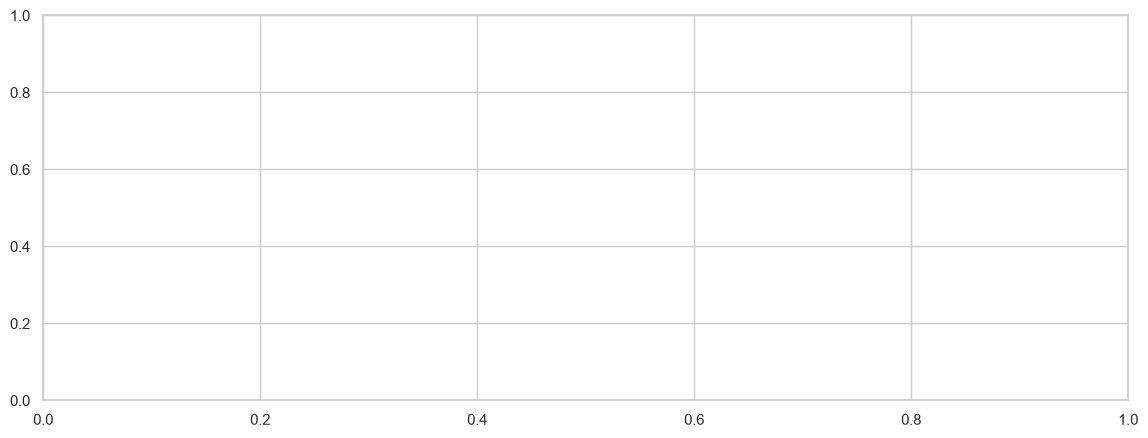

In [16]:
cos_matrix = similarity_profile.pivot(index="caribbean_genre", columns="westafrica_genre", values="cosine_similarity")
euc_matrix = similarity_profile.pivot(index="caribbean_genre", columns="westafrica_genre", values="euclidean_distance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cos_matrix, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_title("Cosine Similarity\n(higher = more similar)")

sns.heatmap(euc_matrix, annot=True, fmt=".2f", cmap="viridis_r", ax=axes[1])
axes[1].set_title("Euclidean Distance\n(lower = more similar)")

plt.tight_layout()
plt.show()


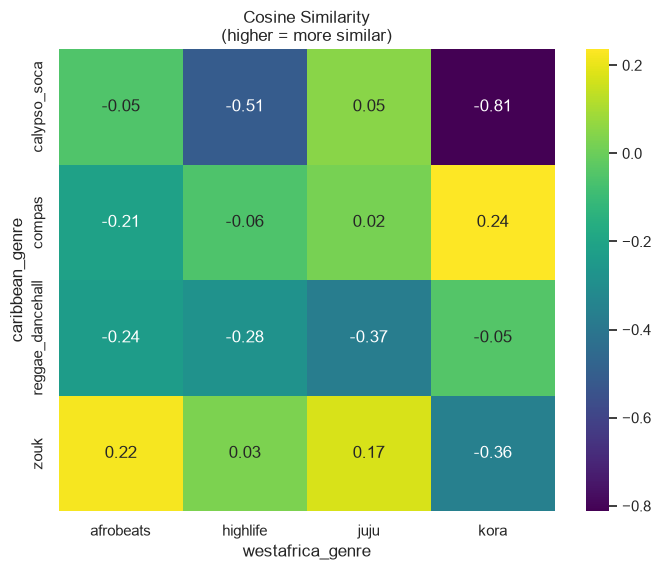

In [19]:
fig, ax = plt.subplots(figsize=(8, 6)) 
sns.heatmap(cos_matrix, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Cosine Similarity\n(higher = more similar)")
plt.show()

## 6. Headline Results

The single closest and furthest genre pairs by each metric — useful as the
top-line answer to "which Caribbean genres are acoustically closest to
West African music."

Note cosine similarity and Euclidean distance can rank pairs differently;
both are shown rather than picking one as "the" answer.


In [9]:
print("Closest pairs by COSINE SIMILARITY:")
display(similarity_profile.sort_values("cosine_similarity", ascending=False).head(5))

print("\nClosest pairs by EUCLIDEAN DISTANCE:")
display(similarity_profile.sort_values("euclidean_distance", ascending=True).head(5))

print("\nFurthest pairs by COSINE SIMILARITY:")
display(similarity_profile.sort_values("cosine_similarity", ascending=True).head(5))


Closest pairs by COSINE SIMILARITY:


,caribbean_genre,westafrica_genre,cosine_similarity,euclidean_distance
0,compas,kora,0.236075,3.652532
1,zouk,afrobeats,0.222711,2.120605
2,zouk,juju,0.171592,2.136176
3,calypso_soca,juju,0.050663,2.538370
4,zouk,highlife,0.028385,2.291304



Closest pairs by EUCLIDEAN DISTANCE:


,caribbean_genre,westafrica_genre,cosine_similarity,euclidean_distance
1,zouk,afrobeats,0.222711,2.120605
5,compas,juju,0.020259,2.135588
2,zouk,juju,0.171592,2.136176
8,compas,highlife,-0.056145,2.189869
4,zouk,highlife,0.028385,2.291304



Furthest pairs by COSINE SIMILARITY:


,caribbean_genre,westafrica_genre,cosine_similarity,euclidean_distance
15,calypso_soca,kora,-0.812347,5.430664
14,calypso_soca,highlife,-0.510889,3.174017
13,reggae_dancehall,juju,-0.370354,2.915663
12,zouk,kora,-0.359546,4.546238
11,reggae_dancehall,highlife,-0.280389,2.795429


In [10]:
# Per-Caribbean-genre summary: which West African genre is it closest to overall?
best_match_per_genre = (
    similarity_profile
    .sort_values("cosine_similarity", ascending=False)
    .groupby("caribbean_genre")
    .first()
    .reset_index()[["caribbean_genre", "westafrica_genre", "cosine_similarity", "euclidean_distance"]]
)
best_match_per_genre


,caribbean_genre,westafrica_genre,cosine_similarity,euclidean_distance
0,calypso_soca,juju,0.050663,2.538370
1,compas,kora,0.236075,3.652532
2,reggae_dancehall,kora,-0.045639,4.213081
3,zouk,afrobeats,0.222711,2.120605


## 7. Feature-Level Similarity

The aggregate metrics above answer "how close overall," but not "close on
*what*." For every genre pair, we look at the per-feature standardized gap
(`abs(centroid_A - centroid_B)`) — small gap means that feature is a point
of acoustic connection between the two genres; large gap means it's a
point of divergence.

We also compute each feature's **contribution to total Euclidean
distance** (its squared gap as a share of the summed squared gaps across
all features), which gives a normalized sense of which features are
driving the overall distance score, not just which have the largest raw
gap.


In [11]:
def feature_level_similarity(genre_a, genre_b, centroids, feature_cols):
    vec_a = centroids.loc[genre_a, feature_cols]
    vec_b = centroids.loc[genre_b, feature_cols]
    gap = (vec_a - vec_b).abs()
    sq_gap = gap ** 2
    contribution = sq_gap / sq_gap.sum()

    out = pd.DataFrame({
        "feature": feature_cols,
        "genre_a_value": vec_a.values,
        "genre_b_value": vec_b.values,
        "abs_gap": gap.values,
        "distance_contribution": contribution.values,
    }).sort_values("abs_gap")  # smallest gap first = closest features

    return out

# Example: feature-level breakdown for the single closest pair found above
top_pair = similarity_profile.iloc[0]
car_g, wa_g = top_pair["caribbean_genre"], top_pair["westafrica_genre"]
print(f"Feature-level similarity: {car_g} vs {wa_g}")

feat_sim = feature_level_similarity(car_g, wa_g, genre_centroids, feature_cols)
print("\nMost similar features (smallest standardized gap):")
display(feat_sim.head(8))

print("\nMost divergent features (largest standardized gap):")
display(feat_sim.sort_values("abs_gap", ascending=False).head(8))


Feature-level similarity: compas vs kora

Most similar features (smallest standardized gap):


,feature,genre_a_value,genre_b_value,abs_gap,distance_contribution
13,log_attack_time_ms,-0.252594,-0.262011,0.009418,0.000007
26,mfcc_13_mean,-0.288592,-0.262250,0.026342,0.000052
5,mean_beat_strength,-0.506874,-0.535327,0.028453,0.000061
12,spectral_flux_mean,-0.654189,-0.712741,0.058553,0.000257
9,dynamic_range_db,-0.118467,-0.024153,0.094313,0.000667
21,mfcc_8_mean,-0.083583,-0.181042,0.097459,0.000712
27,onsets_per_second,-0.058163,0.095150,0.153313,0.001762
22,mfcc_9_mean,-0.298985,-0.139691,0.159294,0.001902



Most divergent features (largest standardized gap):


,feature,genre_a_value,genre_b_value,abs_gap,distance_contribution
15,mfcc_2_mean,0.050547,1.169409,1.118862,0.093835
10,spectral_centroid_mean,-0.075674,-1.163069,1.087395,0.088631
14,mfcc_1_mean,0.021663,-0.932330,0.953993,0.068219
11,spectral_bandwidth_mean,-0.052448,-1.003629,0.951181,0.067817
38,chroma_G#,0.081735,-0.862739,0.944473,0.066864
33,chroma_D#,0.100420,-0.769566,0.869986,0.056733
31,chroma_C#,0.126598,-0.716501,0.843099,0.053281
32,chroma_D,0.129111,-0.632594,0.761705,0.043490


**Results are calculated  for every Caribbean × West African pair**.


In [12]:
all_feature_level = []
for car_genre in CARIBBEAN_GENRES:
    for wa_genre in WESTAFRICA_GENRES:
        fl = feature_level_similarity(car_genre, wa_genre, genre_centroids, feature_cols)
        fl["caribbean_genre"] = car_genre
        fl["westafrica_genre"] = wa_genre
        all_feature_level.append(fl)

feature_level_df = pd.concat(all_feature_level, ignore_index=True)
feature_level_df = feature_level_df[
    ["caribbean_genre", "westafrica_genre", "feature", "genre_a_value", "genre_b_value",
     "abs_gap", "distance_contribution"]
]
feature_level_df.head(10)


,caribbean_genre,westafrica_genre,feature,genre_a_value,genre_b_value,abs_gap,distance_contribution
0,calypso_soca,afrobeats,mfcc_6_mean,-0.025576,-0.029259,0.003683,0.000002
1,calypso_soca,afrobeats,chroma_D,0.110858,0.127412,0.016555,0.000037
2,calypso_soca,afrobeats,chroma_G,0.242124,0.264860,0.022736,0.000070
3,calypso_soca,afrobeats,log_attack_time_ms,0.043504,0.106616,0.063111,0.000536
4,calypso_soca,afrobeats,chroma_C#,0.177460,0.109288,0.068172,0.000625
5,calypso_soca,afrobeats,chroma_F,0.245741,0.131738,0.114003,0.001748
6,calypso_soca,afrobeats,chroma_C,0.078952,-0.052105,0.131057,0.002311
7,calypso_soca,afrobeats,spectral_bandwidth_mean,0.309043,0.168840,0.140203,0.002644
8,calypso_soca,afrobeats,dynamic_range_db,-0.162593,0.016855,0.179448,0.004332
9,calypso_soca,afrobeats,mfcc_7_mean,0.040060,-0.150218,0.190278,0.004871


## 8. Which Features Drive Similarity/Difference Overall?

Averaging `distance_contribution` across all genre pairs shows which
features tend to matter most for separating Caribbean from West African
genres in general, versus which tend to be already similar across the
board (low average contribution = genres tend to agree on this feature
regardless of pairing).


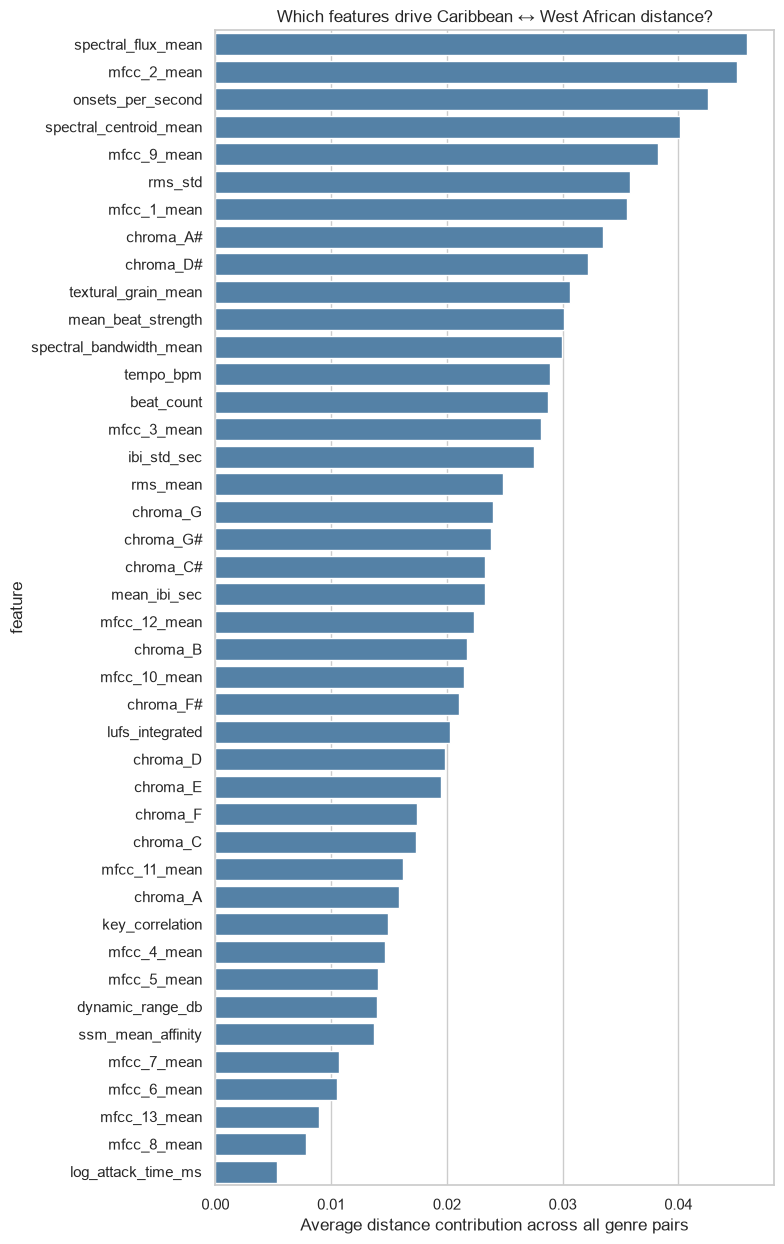

feature
spectral_flux_mean         0.045961
mfcc_2_mean                0.045058
onsets_per_second          0.042573
spectral_centroid_mean     0.040154
mfcc_9_mean                0.038242
rms_std                    0.035845
mfcc_1_mean                0.035579
chroma_A#                  0.033486
chroma_D#                  0.032155
textural_grain_mean        0.030665
mean_beat_strength         0.030151
spectral_bandwidth_mean    0.029967
tempo_bpm                  0.028889
beat_count                 0.028736
mfcc_3_mean                0.028123
ibi_std_sec                0.027547
rms_mean                   0.024865
chroma_G                   0.023977
chroma_G#                  0.023831
chroma_C#                  0.023327
mean_ibi_sec               0.023259
mfcc_12_mean               0.022383
chroma_B                   0.021779
mfcc_10_mean               0.021510
chroma_F#                  0.021029
lufs_integrated            0.020234
chroma_D                   0.019813
chroma_E            

In [13]:
avg_contribution = (
    feature_level_df
    .groupby("feature")["distance_contribution"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, max(4, 0.3 * len(avg_contribution))))
sns.barplot(x=avg_contribution.values, y=avg_contribution.index, color="steelblue")
plt.xlabel("Average distance contribution across all genre pairs")
plt.title("Which features drive Caribbean \u2194 West African distance?")
plt.tight_layout()
plt.show()

avg_contribution


## 9. Save Results


In [14]:
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

similarity_path = OUT_DIR / "genre_similarity_profile.csv"
similarity_profile.to_csv(similarity_path, index=False)
print(f"Saved {len(similarity_profile)} genre-pair rows to {similarity_path}")

feature_level_path = OUT_DIR / "feature_level_similarity.csv"
feature_level_df.to_csv(feature_level_path, index=False)
print(f"Saved {len(feature_level_df)} feature-level rows to {feature_level_path}")


Saved 16 genre-pair rows to ../data/processed/genre_similarity_profile.csv
Saved 672 feature-level rows to ../data/processed/feature_level_similarity.csv
